# Logical CNOT — Lattice Surgery

Lattice Surgery CNOT uses three surface code patches: Control (C), Target (T), Ancilla (A).

Layout:
```
  A — T   (XX merge)
  |       (ZZ merge)
  C
```

Two protocol variants (set `PROTOCOL` in the config cell):

| `PROTOCOL` | Ancilla init | Step 1 | Step 2 | Ancilla meas |
|---|---|---|---|---|
| `"ZZ_XX"` | \|+⟩ | ZZ merge (C–A) | XX merge (T–A) | Z |
| `"XX_ZZ"` | \|0⟩ | XX merge (T–A) | ZZ merge (C–A) | X |

Five sub-experiments probe all logical input/output basis combinations:

| Sub-experiment | Init C | Init T | Meas C | Meas T |
|---|---|---|---|---|
| ZZ_ZZ | Z | Z | Z | Z |
| ZX_ZX | Z | X | Z | X |
| XZ_XX | X | Z | X | X |
| XZ_ZZ | X | Z | Z | Z |
| XX_XX | X | X | X | X |

Average over the sub-experiments to get a comprehensive LER estimation of the protocol: 1/4 * (ZZ_ZZ + ZX_ZX + 1/2 * (XZ_XX + XZ_ZZ) + XX_XX).  
Code: Unrotated Surface Code, d=3, p=1e-3.

In [1]:
import sys
from pathlib import Path
import io, contextlib

ROOT = Path("../../lightstim").resolve()  # vendored LightStim snapshot
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lightstim.protocols.cnot_ls import CNOTLSExperiment
from lightstim.qec_code.surface_code.unrotated import UnrotatedSurfaceCodeExtractionBlock
from lightstim.noise.config import NoiseConfig
from lightstim.simulation.decoder_backend import SimulationPipeline, DecoderConfig

In [2]:
d = 3
p = 1e-3
rounds = 2   # use rounds=d to match paper benchmark convention; use rounds=2 if you want to simplify the visualization
noise_params = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)

# Protocol variant — controls ancilla init state, which determines merge order:
#   "ZZ_XX" — ancilla |+⟩, ZZ merge (C–A) first then XX merge (T–A), measure A in Z
#   "XX_ZZ" — ancilla |0⟩, XX merge (T–A) first then ZZ merge (C–A), measure A in X
PROTOCOL = "ZZ_XX"

CNOT_SUB_EXPERIMENTS = [
    # (label,  init_C, init_T, meas_C, meas_T)
    ("ZZ_ZZ", "Z", "Z", "Z", "Z"),
    ("ZX_ZX", "Z", "X", "Z", "X"),
    ("XZ_XX", "X", "Z", "X", "X"),
    ("XZ_ZZ", "X", "Z", "Z", "Z"),
    ("XX_XX", "X", "X", "X", "X"),
]

## Build Circuits

In [3]:
ancilla_init  = "X" if PROTOCOL == "ZZ_XX" else "Z"   # |+⟩ for ZZ_XX, |0⟩ for XX_ZZ

circuits = {}
for sub, ic, it, mc, mt in CNOT_SUB_EXPERIMENTS:
    with contextlib.redirect_stdout(io.StringIO()):
        exp = CNOTLSExperiment(
            patch_configs={
                "c": {"distance": d},
                "t": {"distance": d},
                "a": {"distance": d},
            },
            offset_ta=(2 * d, 0),
            offset_ca=(0, 2 * d),
            initial_state_dict={"a": ancilla_init, "c": ic, "t": it},
            measure_state_dict={"a": "Z", "c": mc, "t": mt},  # ancilla meas auto-corrected by CNOTLSExperiment
            extraction_block_class=UnrotatedSurfaceCodeExtractionBlock,
            rounds=rounds,
            noise_params=noise_params,
        )
        circuits[sub] = exp.build()
    c = circuits[sub]
    print(f"{sub}: {c.num_qubits} qubits, {c.num_detectors} detectors, {c.num_observables} observables")

ZZ_ZZ: 85 qubits, 222 detectors, 2 observables
ZX_ZX: 85 qubits, 222 detectors, 2 observables
XZ_XX: 85 qubits, 222 detectors, 1 observables
XZ_ZZ: 85 qubits, 222 detectors, 1 observables


XX_XX: 85 qubits, 222 detectors, 2 observables


## Detector Slice (ZZ_ZZ sub-experiment)

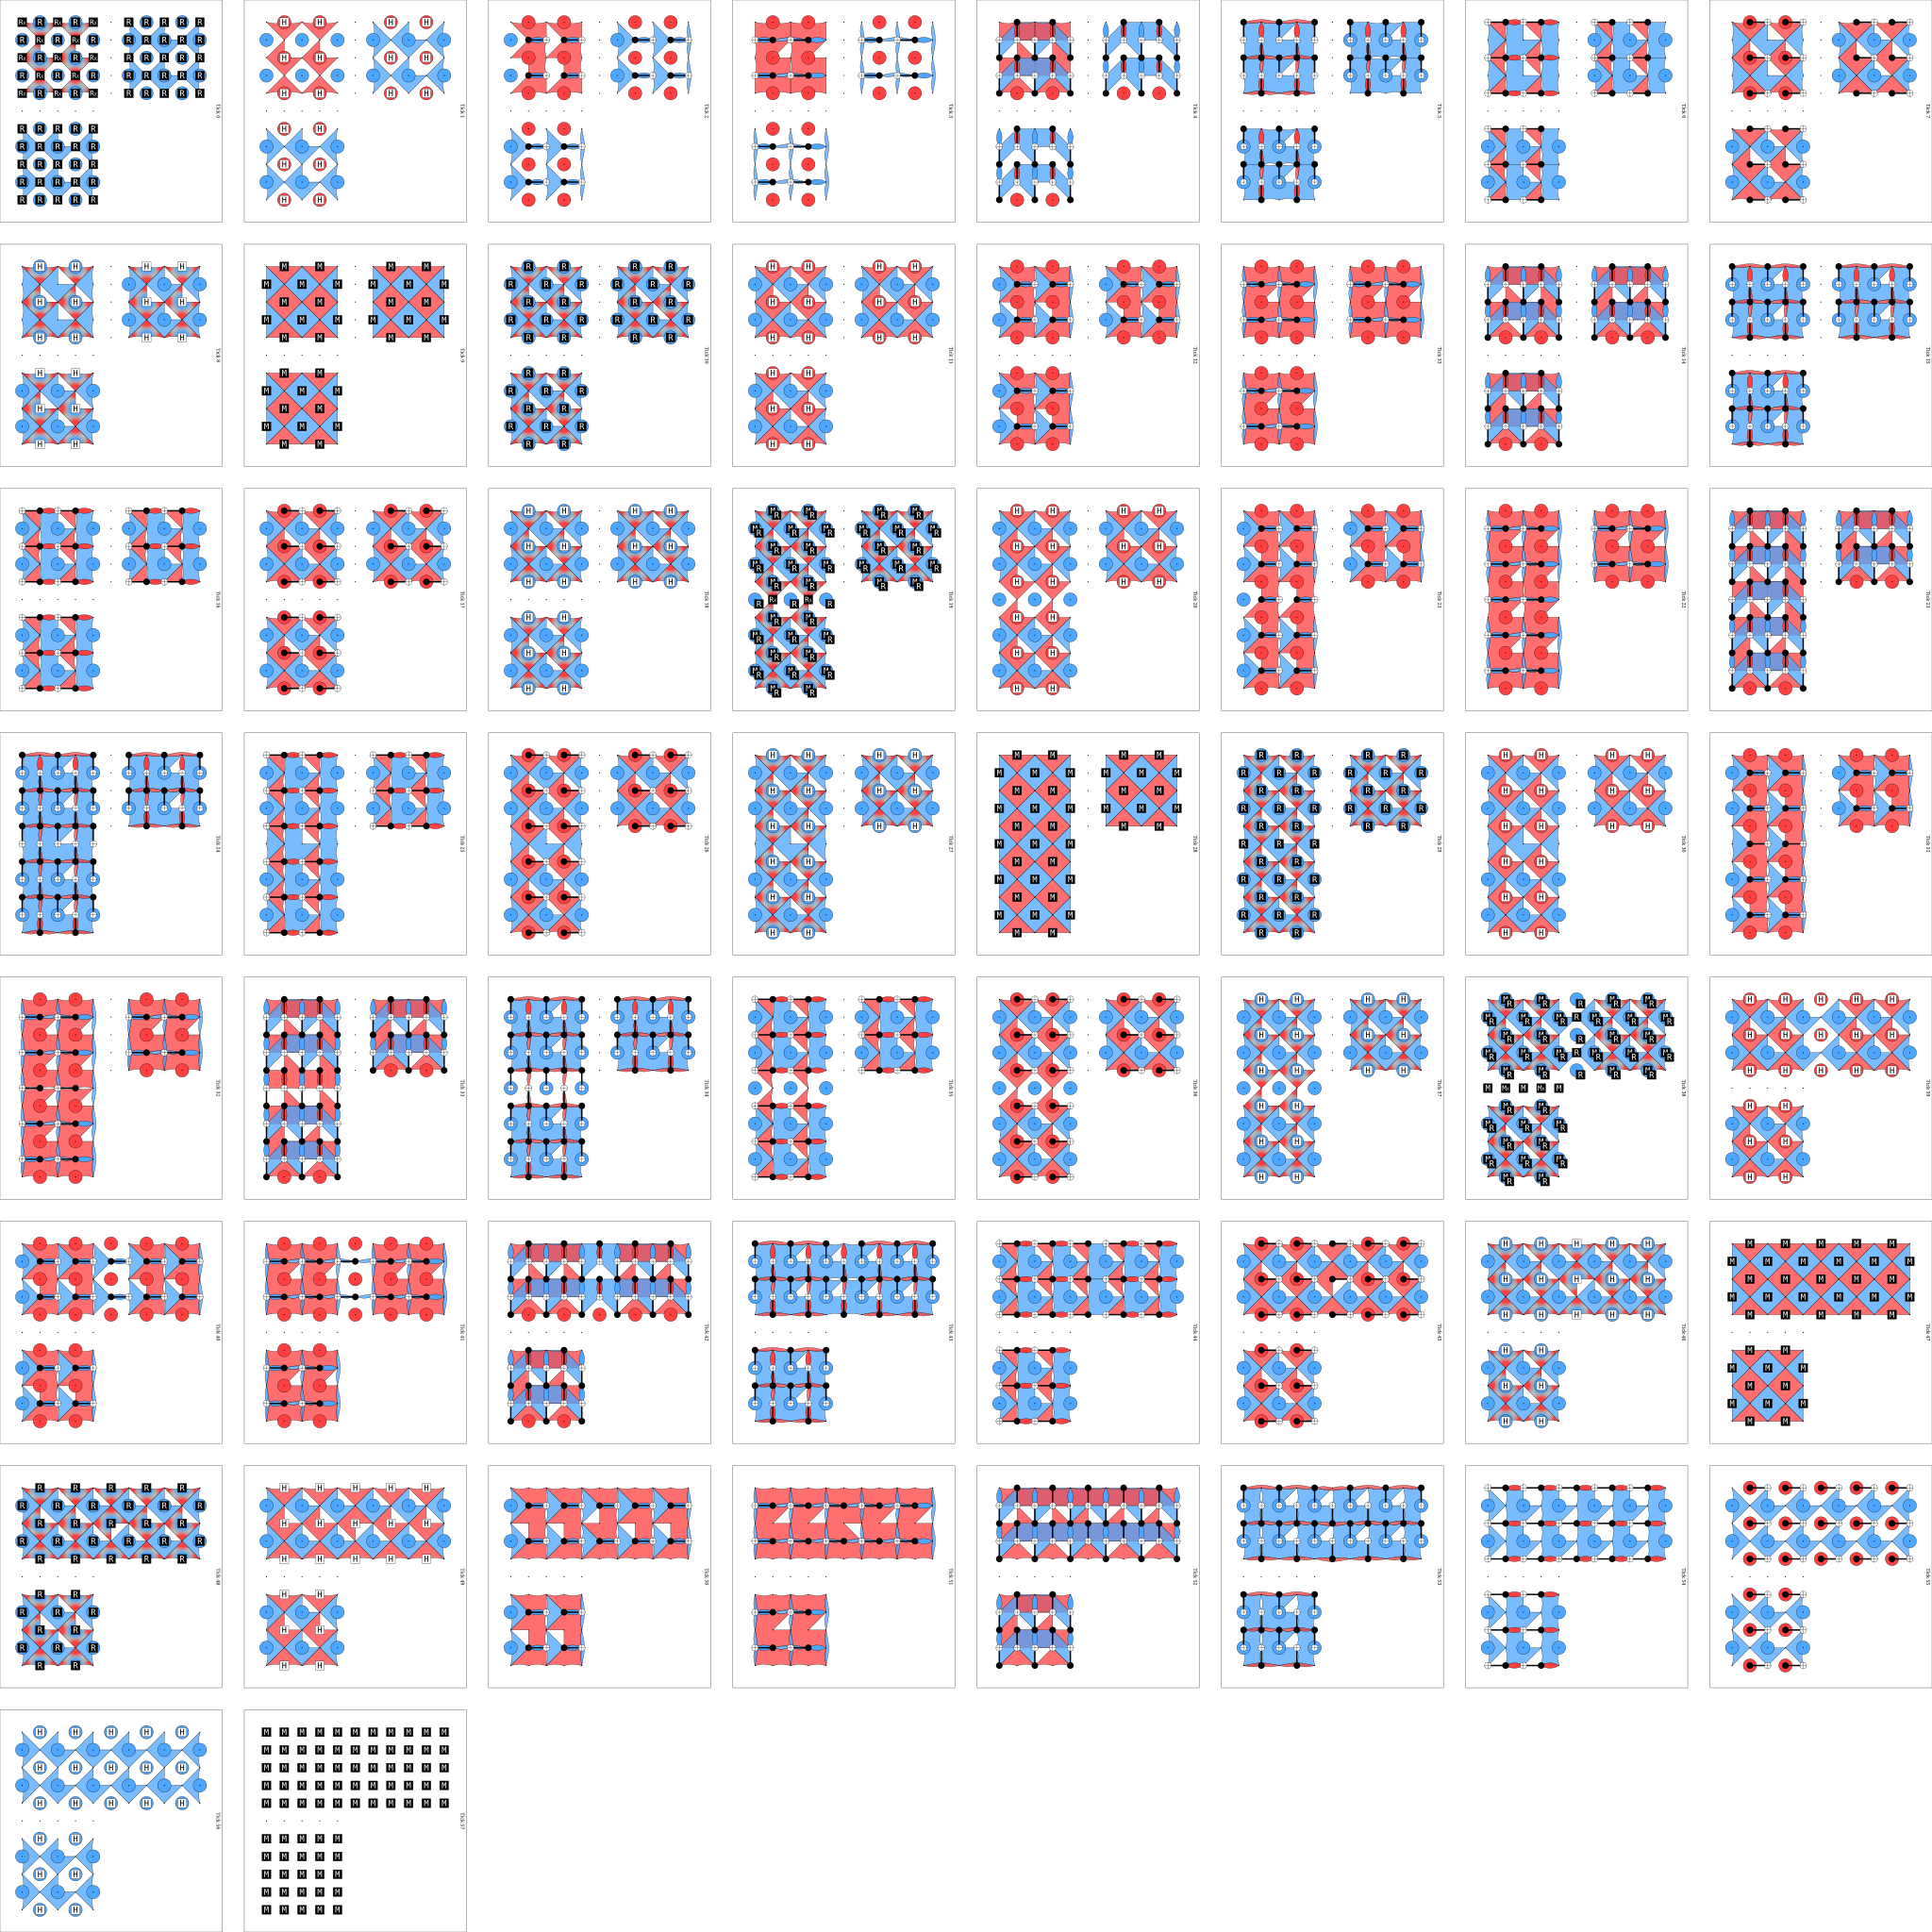

In [4]:
circuits["ZZ_ZZ"].without_noise().diagram("detslice-with-ops-svg")

## Noiseless Sanity Check

In [5]:
for sub, circ in circuits.items():
    sampler = circ.without_noise().compile_detector_sampler()
    det, obs = sampler.sample(shots=200, separate_observables=True)
    print(f"{sub}: clean={not det.any() and not obs.any()}")

ZZ_ZZ: clean=True
ZX_ZX: clean=True
XZ_XX: clean=True
XZ_ZZ: clean=True
XX_XX: clean=True


## Simulation with Pymatching

In [6]:
pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("pymatching", backend="cpu"),
    max_shots=100_000,
    max_errors=50,
    num_workers=4,
    print_progress=False,
)

results = {}
for sub, circ in circuits.items():
    stats = pipeline.run(circ)
    results[sub] = stats
    print(f"{sub}: LER={stats.logical_error_rate:.2e}  ({stats.errors} errors / {stats.shots:,} shots)")

ZZ_ZZ: LER=1.43e-02  (570 errors / 40,000 shots)


ZX_ZX: LER=3.50e-03  (175 errors / 50,000 shots)


XZ_XX: LER=1.68e-02  (673 errors / 40,000 shots)


XZ_ZZ: LER=1.48e-02  (593 errors / 40,000 shots)


XX_XX: LER=2.04e-02  (818 errors / 40,000 shots)


## LER vs Physical Error Rate

Sweep the physical error rate `p ∈ {1e-3, 2e-3, 3e-3, 5e-3, 7e-3, 1e-2}` and plot the **mean logical error rate over the 5 sub-experiments**, one curve per code distance (`rounds = d`, paper convention). Below threshold the larger code suppresses errors (LER(d=5) < LER(d=3)); the two curves cross in the threshold region (`p ≈ 5e-3`–`1e-2`).

  d         p   mean LER (over 5 sub-experiments)
------------------------------------------------


  3     1e-03   7.163e-03


  3     2e-03   2.476e-02


  3     3e-03   5.241e-02


  3     5e-03   1.311e-01


...

  7     2e-03   7.663e-04


  7     3e-03   5.160e-03


  7     5e-03   5.518e-02


  7     7e-03   2.132e-01


  7     1e-02   5.121e-01


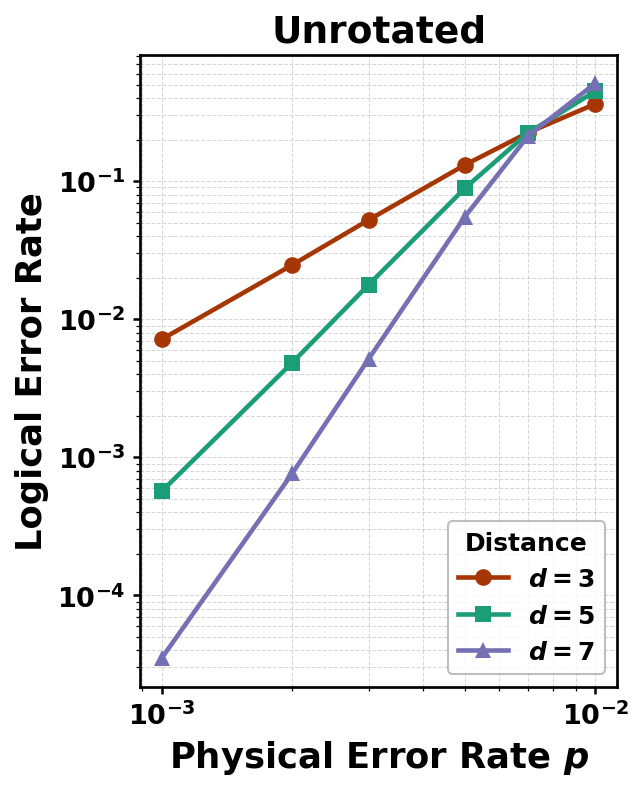

In [7]:
# ── LER vs Physical Error Rate ────────────────────────────────────────────────
# Sweep the physical error rate and plot the mean logical error rate over the 5
# sub-experiments, one curve per code distance (rounds = d, paper convention).
# Below threshold the larger code wins (LER(d=5) < LER(d=3)); the curves cross
# in the threshold region (p ~ 5e-3 to 1e-2).
import logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from lightstim.plot.styles import apply_paper_style, bold_ticks, PALETTE_DISTANCE
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # silence bold-font warnings

P_SWEEP   = [1e-3, 2e-3, 3e-3, 5e-3, 7e-3, 1e-2]
DISTANCES = [3, 5, 7]
MARKERS   = {3: "o", 5: "s", 7: "^"}

sweep_pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("pymatching", backend="cpu"),
    max_shots=100_000_000,
    max_errors=200,
    num_workers=32,
    print_progress=False,
)

TITLE = "Unrotated"
ancilla_init = "X" if PROTOCOL == "ZZ_XX" else "Z"   # |+> for ZZ_XX, |0> for XX_ZZ

def build_cnot_p(dd, ic, it, mc, mt, pp):
    "Build one unrotated LS-CNOT sub-experiment at distance dd, error rate pp (rounds=dd)."
    import io, contextlib
    noise = NoiseConfig(p_idle=pp, p_1q=pp, p_2q=pp, p_meas=pp, p_reset=pp)
    with contextlib.redirect_stdout(io.StringIO()):
        exp = CNOTLSExperiment(
            patch_configs={"c": {"distance": dd}, "t": {"distance": dd}, "a": {"distance": dd}},
            offset_ta=(2 * dd, 0),
            offset_ca=(0, 2 * dd),
            initial_state_dict={"a": ancilla_init, "c": ic, "t": it},
            measure_state_dict={"a": "Z", "c": mc, "t": mt},
            extraction_block_class=UnrotatedSurfaceCodeExtractionBlock,
            rounds=dd,
            noise_params=noise,
        )
        return exp.build()

ler_curves = {dd: [] for dd in DISTANCES}
print(f"{'d':>3} {'p':>9}   mean LER (over 5 sub-experiments)")
print("-" * 48)
for dd in DISTANCES:
    for pp in P_SWEEP:
        lers = [sweep_pipeline.run(build_cnot_p(dd, ic, it, mc, mt, pp)).logical_error_rate
                for sub, ic, it, mc, mt in CNOT_SUB_EXPERIMENTS]
        mean_ler = float(np.mean(lers))
        ler_curves[dd].append(mean_ler)
        print(f"{dd:>3} {pp:>9.0e}   {mean_ler:.3e}")

apply_paper_style()
fig, ax = plt.subplots(figsize=(4.5, 5.5))
proxies = []
for dd in DISTANCES:
    color  = PALETTE_DISTANCE.get(dd, "gray")
    marker = MARKERS.get(dd, "o")
    _y = np.array(ler_curves[dd], dtype=float)
    _y[_y <= 0] = np.nan  # drop zero-error points (e.g. d=7 low-p) from the log plot
    ax.loglog(P_SWEEP, _y, marker=marker, color=color,
              linestyle="-", markeredgecolor="none")
    proxies.append(mlines.Line2D([], [], color=color, ls="-", marker=marker,
                                 markersize=8, markeredgecolor="none", label=f"$d = {dd}$"))

ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate")
ax.set_title(TITLE)
ax.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.5)
bold_ticks(ax)
leg = ax.legend(handles=proxies, title="Distance", loc="lower right",
                frameon=True, framealpha=0.85)
leg.get_title().set_fontweight("bold")
fig.tight_layout()
plt.show()
